In [ ]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


In [ ]:
!wget -q https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip


In [ ]:
!unzip -q "human+activity+recognition+using+smartphones.zip"


In [ ]:
!ls


 human+activity+recognition+using+smartphones.zip  'UCI HAR Dataset.names'
 sample_data					   'UCI HAR Dataset.zip'


In [ ]:
!find . -maxdepth 2 -type d

.
./.config
./.config/configurations
./.config/logs
./sample_data


In [ ]:
!unzip -q "UCI HAR Dataset.zip"


In [ ]:
!ls

 human+activity+recognition+using+smartphones.zip  'UCI HAR Dataset'
 __MACOSX					   'UCI HAR Dataset.names'
 sample_data					   'UCI HAR Dataset.zip'


In [ ]:
!ls "UCI HAR Dataset"


activity_labels.txt  features_info.txt	features.txt  README.txt  test	train


In [ ]:
!ls "UCI HAR Dataset/train"


'Inertial Signals'   subject_train.txt	 X_train.txt   y_train.txt


In [ ]:
X_train=pd.read_csv("UCI HAR Dataset/train/X_train.txt",delim_whitespace=True,header=None)
print(X_train.shape)

/tmp/ipykernel_445/3953908865.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train=pd.read_csv("UCI HAR Dataset/train/X_train.txt",delim_whitespace=True,header=None)


(7352, 561)


In [ ]:
y_train=pd.read_csv("UCI HAR Dataset/train/y_train.txt",delim_whitespace=True,header=None)
print(y_train.shape)

(7352, 1)


/tmp/ipykernel_445/2507825625.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train=pd.read_csv("UCI HAR Dataset/train/y_train.txt",delim_whitespace=True,header=None)


In [ ]:
print(y_train.head())

   0
0  5
1  5
2  5
3  5
4  5


In [ ]:
activity_labels=pd.read_csv("UCI HAR Dataset/activity_labels.txt",delim_whitespace=True,header=None)
print(activity_labels.shape)

(6, 2)


/tmp/ipykernel_445/2091839730.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  activity_labels=pd.read_csv("UCI HAR Dataset/activity_labels.txt",delim_whitespace=True,header=None)


In [ ]:
print(activity_labels)

   0                   1
0  1             WALKING
1  2    WALKING_UPSTAIRS
2  3  WALKING_DOWNSTAIRS
3  4             SITTING
4  5            STANDING
5  6              LAYING


In [ ]:
x_test=pd.read_csv("UCI HAR Dataset/test/X_test.txt",delim_whitespace=True,header=None)
print(x_test.shape)

/tmp/ipykernel_445/2451219071.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  x_test=pd.read_csv("UCI HAR Dataset/test/X_test.txt",delim_whitespace=True,header=None)


(2947, 561)


In [ ]:
y_test=pd.read_csv('UCI HAR Dataset/test/y_test.txt',delim_whitespace=True,header=None)
print(y_test.shape)

(2947, 1)


/tmp/ipykernel_445/1455328158.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_test=pd.read_csv('UCI HAR Dataset/test/y_test.txt',delim_whitespace=True,header=None)


In [ ]:
print(y_test.head())

   0
0  5
1  5
2  5
3  5
4  5


In [ ]:
y_train=y_train-1
y_train_cat=to_categorical(y_train.values.flatten(),num_classes=6)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model=Sequential(
    [
        Dense(128,activation='relu',input_shape=(561,)),
        Dense(64,activation='relu'),
        Dense(32,activation='relu'),
        Dense(6,activation='softmax')
    ]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,470 (322.15 KB)

 Trainable params: 82,470 (322.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(X_train,y_train_cat,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8247 - loss: 0.4820 - val_accuracy: 0.9062 - val_loss: 0.2431
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9356 - loss: 0.1674 - val_accuracy: 0.9218 - val_loss: 0.1794
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9570 - loss: 0.1134 - val_accuracy: 0.9361 - val_loss: 0.1473
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9536 - loss: 0.1157 - val_accuracy: 0.9436 - val_loss: 0.1340
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9667 - loss: 0.0843 - val_accuracy: 0.9470 - val_loss: 0.1169
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9759 - loss: 0.0655 - val_accuracy: 0.9334 - val_loss: 0.1526
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9774 - loss: 0.0609 - val_accuracy: 0.9402 - val_loss: 0.1636
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9776 - loss: 0.0582 - val_accuracy: 0.

In [ ]:
y_pred_proba = model.predict(X_train.iloc[:1])

print(y_pred_proba)
print(y_pred_proba.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[1.9301863e-06 7.7849072e-06 1.0053860e-05 1.7121506e-03 9.9826306e-01
  4.9407395e-06]]
(1, 6)


In [ ]:
background_data_np = X_train.sample(
    100,
    random_state=42
).to_numpy(dtype=np.float32)


In [ ]:
#understanding purpose

In [ ]:
df = pd.concat([
    pd.concat([X_train, x_test], ignore_index=True),
    pd.concat([y_train, y_test], ignore_index=True)
], axis=1)

print(df.shape)


(10299, 562)


In [ ]:
df

,0,1,2,3,4,5,6,7,8,9,...,552,553,554,555,556,557,558,559,560,0
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,4
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,4
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,4
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,4
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10294,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784,2
10295,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412,2
10296,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184,2
10297,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563,2


In [ ]:
import shap

In [ ]:
# Feature names (needed to label the top features later — wasn't loaded yet)
features = pd.read_csv("UCI HAR Dataset/features.txt", sep=r"\s+", header=None)
print(features.shape)

(561, 2)


In [ ]:
#training for shap
explainer = shap.DeepExplainer(model, background_data_np)

/usr/local/lib/python3.13/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 561))']
  warnings.warn(msg)


In [ ]:
sample_np = X_train.iloc[:1].to_numpy(dtype=np.float32)
print(sample_np.shape)

(1, 561)


In [ ]:
# shap_values_all will have shape (num_samples, 561 features, 6 classes)
shap_values_all = explainer.shap_values(sample_np)
print(type(shap_values_all))
print(np.array(shap_values_all).shape)

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 561))']
  warnings.warn(msg)


<class 'numpy.ndarray'>
(1, 561, 6)


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 561))']
  warnings.warn(msg)


In [ ]:
# Pull out just the Standing column (class index 4) for our one sample
standing_shap_value = np.array(shap_values_all)[0, :, 4]
print(standing_shap_value.shape)

(561,)


In [ ]:
# Importance = size of impact, regardless of direction
shap_importance = np.abs(standing_shap_value)
print(shap_importance.shape)

(561,)


In [ ]:
top_indices = np.argsort(shap_importance)[-10:][::-1]
print(top_indices)

[149 189 369 186 372  41  50  53 105 150]


In [ ]:
for i in top_indices:
    print(features.iloc[i, 1], "|", shap_importance[i], "|", standing_shap_value[i])

tBodyGyro-arCoeff()-Y,1 | 0.03337709605693817 | 0.03337709605693817
tBodyGyroJerk-arCoeff()-Y,1 | 0.033217474818229675 | 0.033217474818229675
fBodyAccJerk-maxInds-X | 0.027670972049236298 | 0.027670972049236298
tBodyGyroJerk-arCoeff()-X,2 | 0.02634548209607601 | 0.02634548209607601
fBodyAccJerk-meanFreq()-X | 0.024754785001277924 | 0.024754785001277924
tGravityAcc-mean()-Y | 0.024592256173491478 | 0.024592256173491478
tGravityAcc-max()-Y | 0.02434249222278595 | 0.02434249222278595
tGravityAcc-min()-Y | 0.023368623107671738 | 0.023368623107671738
tBodyAccJerk-arCoeff()-X,1 | 0.02127244882285595 | 0.02127244882285595
tBodyGyro-arCoeff()-Y,2 | 0.020855285227298737 | 0.020855285227298737


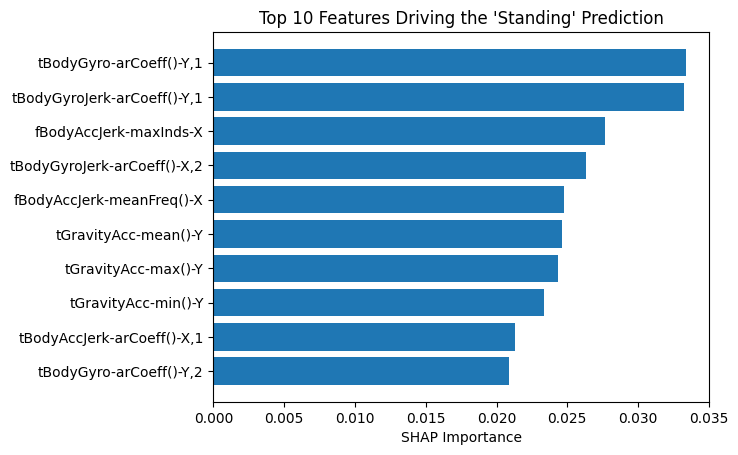

In [ ]:
import matplotlib.pyplot as plt

plt.barh(
    [features.iloc[i, 1] for i in top_indices[::-1]],
    [shap_importance[i] for i in top_indices[::-1]]
)
plt.xlabel("SHAP Importance")
plt.title("Top 10 Features Driving the 'Standing' Prediction")
plt.show()

In [ ]:
for i in top_indices:
    print(features.iloc[i, 1], "|", standing_shap_value[i])


tBodyGyro-arCoeff()-Y,1 | 0.03337709605693817
tBodyGyroJerk-arCoeff()-Y,1 | 0.033217474818229675
fBodyAccJerk-maxInds-X | 0.027670972049236298
tBodyGyroJerk-arCoeff()-X,2 | 0.02634548209607601
fBodyAccJerk-meanFreq()-X | 0.024754785001277924
tGravityAcc-mean()-Y | 0.024592256173491478
tGravityAcc-max()-Y | 0.02434249222278595
tGravityAcc-min()-Y | 0.023368623107671738
tBodyAccJerk-arCoeff()-X,1 | 0.02127244882285595
tBodyGyro-arCoeff()-Y,2 | 0.020855285227298737


In [ ]:
#LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=c17f0f2f094e4fcb2dde6833e5eb2881f9f182e122907416f660410976c677b3
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


LIME PART

In [ ]:
import lime

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
explainer_lime=LimeTabularExplainer(
    X_train.to_numpy(),
    feature_names=features.iloc[:,1].to_list(),
    class_names=activity_labels.iloc[:,1].to_list(),
    mode='classification'
)

In [ ]:
sample = X_train.iloc[:1]
sample_np_lime=sample.to_numpy(dtype=np.float32)

In [ ]:
lime_expliantion=explainer_lime.explain_instance(
    sample_np_lime[0],
    model.predict,
    num_features=10,
    labels=[4]
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
lime_expliantion.as_list(label=4)

[('tBodyGyroJerk-arCoeff()-X,2 <= -0.09', 0.058704100072488705),
 ('tBodyGyroJerk-arCoeff()-X,1 > 0.11', -0.03410690332524413),
 ('-0.25 < tGravityAcc-max()-Y <= -0.15', 0.03322180497923204),
 ('tBodyAcc-entropy()-Z <= -0.51', 0.025564474187672052),
 ('tBodyGyro-arCoeff()-X,1 > -0.02', -0.0252855490951302),
 ('fBodyGyro-entropy()-Z <= -0.78', 0.0248002705994511),
 ('fBodyGyro-meanFreq()-Z > 0.13', -0.024472076911204944),
 ('tBodyGyro-arCoeff()-X,3 > 0.29', 0.023744063414311404),
 ('fBodyAccJerk-meanFreq()-Z > 0.10', 0.02337749667894303),
 ('tBodyGyroJerk-arCoeff()-X,3 > 0.30', -0.020394377086702876)]

In [ ]:
lime_results = lime_expliantion.as_list(label=4)

lime_results


[('tBodyGyroJerk-arCoeff()-X,2 <= -0.09', 0.058704100072488705),
 ('tBodyGyroJerk-arCoeff()-X,1 > 0.11', -0.03410690332524413),
 ('-0.25 < tGravityAcc-max()-Y <= -0.15', 0.03322180497923204),
 ('tBodyAcc-entropy()-Z <= -0.51', 0.025564474187672052),
 ('tBodyGyro-arCoeff()-X,1 > -0.02', -0.0252855490951302),
 ('fBodyGyro-entropy()-Z <= -0.78', 0.0248002705994511),
 ('fBodyGyro-meanFreq()-Z > 0.13', -0.024472076911204944),
 ('tBodyGyro-arCoeff()-X,3 > 0.29', 0.023744063414311404),
 ('fBodyAccJerk-meanFreq()-Z > 0.10', 0.02337749667894303),
 ('tBodyGyroJerk-arCoeff()-X,3 > 0.30', -0.020394377086702876)]

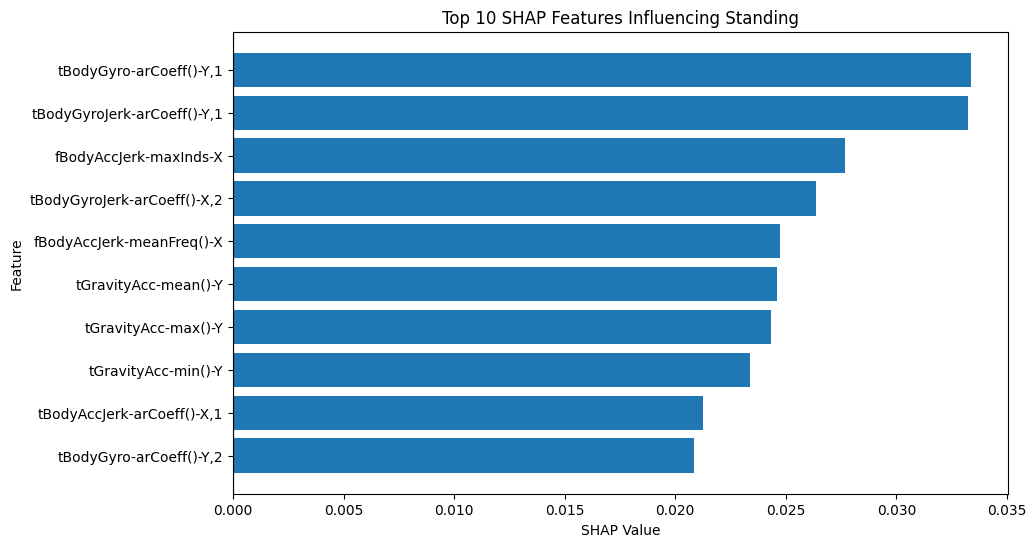

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    [features.iloc[i, 1] for i in top_indices[::-1]],
    [standing_shap_value[i] for i in top_indices[::-1]]
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("Top 10 SHAP Features Influencing Standing")

plt.axvline(0, color="black", linewidth=0.8)

plt.show()


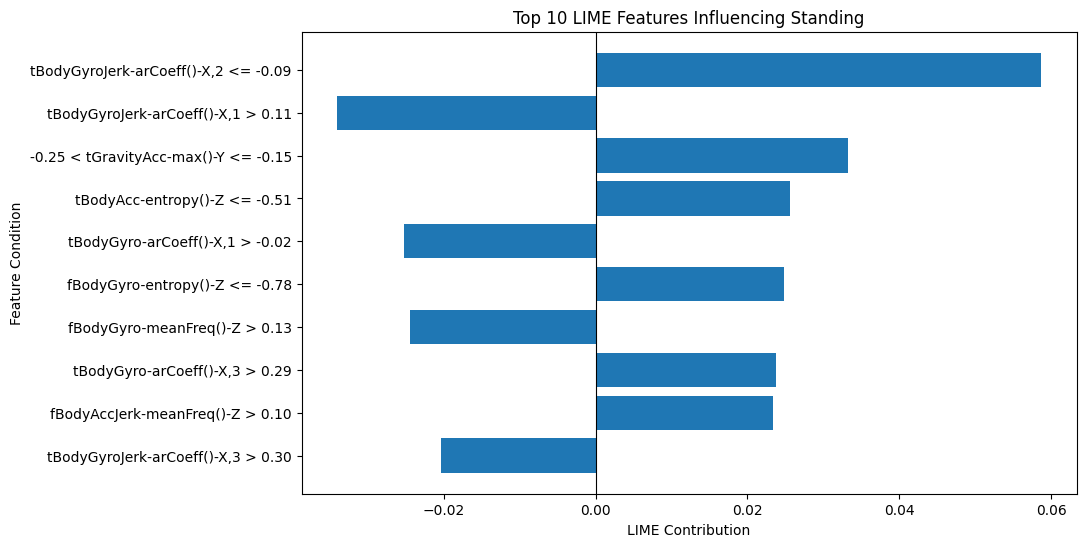

In [ ]:
lime_features = [x[0] for x in lime_results]
lime_values = [x[1] for x in lime_results]

plt.figure(figsize=(10, 6))

plt.barh(lime_features[::-1], lime_values[::-1])

plt.xlabel("LIME Contribution")
plt.ylabel("Feature Condition")
plt.title("Top 10 LIME Features Influencing Standing")

plt.axvline(0, color="black", linewidth=0.8)

plt.show()


In [ ]:
shap_features = [
    features.iloc[i, 1]
    for i in top_indices
]

lime_features = [
    item[0].split(" > ")[0].split(" <= ")[0].strip()
    for item in lime_results
]

common_features = set(shap_features) & set(lime_features)

print(common_features)


{'tBodyGyroJerk-arCoeff()-X,2'}


In [ ]:
for feature in common_features:
    shap_index = shap_features.index(feature)
    shap_value = standing_shap_value[top_indices[shap_index]]

    lime_value = next(
        value for name, value in lime_results
        if feature in name
    )

    print(feature)
    print("SHAP:", shap_value)
    print("LIME:", lime_value)
    print()


tBodyGyroJerk-arCoeff()-X,2
SHAP: 0.02634548209607601
LIME: 0.058704100072488705



In [ ]:
for feature in common_features:
    shap_index = shap_features.index(feature)
    shap_value = standing_shap_value[top_indices[shap_index]]

    lime_value = next(
        value for name, value in lime_results
        if feature in name
    )

    print(feature)
    print("SHAP:", "Toward Standing" if shap_value > 0 else "Away from Standing")
    print("LIME:", "Toward Standing" if lime_value > 0 else "Away from Standing")
    print()


tBodyGyroJerk-arCoeff()-X,2
SHAP: Toward Standing
LIME: Toward Standing

